# Задание 4. Подбор параметров по спектру ТДС

Определим концентрацию ловушек $n$ и энергию выхода $E_p$ по заданному спектру ТДС.

Модель содержит один тип ловушек. Перед началом нагрева ловушки заполнены, а концентрация подвижного водорода равна нулю.


## Модель ТДС


In [1]:
import festim as F
import numpy as np
import matplotlib.pyplot as plt

D_0 = 4.1e-7
E_D = 0.39

avogadro = 6.02214076e23
w_atom_density = 6.3e28 / avogadro


def temperature(t):
    return 300.0 + 5.0 * t


def run_tds(trap_fraction, detrapping_energy):
    model = F.HydrogenTransportProblem()

    H = F.Species("H")
    trapped_H = F.Species(
        "H_trapped",
        mobile=False,
    )
    model.species = [H, trapped_H]

    thickness = 20e-6
    model.mesh = F.Mesh1D(
        np.linspace(0.0, thickness, num=200)
    )

    tungsten = F.Material(
        D_0=D_0,
        E_D=E_D,
    )

    left = F.SurfaceSubdomain1D(id=1, x=0.0)
    right = F.SurfaceSubdomain1D(
        id=2,
        x=thickness,
    )
    volume = F.VolumeSubdomain1D(
        id=3,
        borders=[0.0, thickness],
        material=tungsten,
    )

    model.subdomains = [left, right, volume]

    trap_concentration = (
        trap_fraction * w_atom_density
    )

    empty_traps = F.ImplicitSpecies(
        n=trap_concentration,
        others=[trapped_H],
    )

    model.reactions = [
        F.Reaction(
            reactant=[H, empty_traps],
            product=[trapped_H],
            k_0=(
                D_0
                / (
                    1.1e-10**2
                    * 6
                    * w_atom_density
                )
            ),
            E_k=E_D,
            p_0=1e13,
            E_p=detrapping_energy,
            volume=volume,
        )
    ]

    model.initial_conditions = [
        F.InitialConcentration(
            species=trapped_H,
            value=trap_concentration,
            volume=volume,
        )
    ]

    model.boundary_conditions = [
        F.FixedConcentrationBC(
            subdomain=surface,
            value=0.0,
            species=H,
        )
        for surface in [left, right]
    ]

    model.temperature = temperature

    model.settings = F.Settings(
        atol=1e-10,
        rtol=1e-10,
        final_time=140.0,
        max_iterations=50,
        stepsize=F.Stepsize(
            initial_value=0.01,
            growth_factor=1.2,
            cutback_factor=0.9,
            target_nb_iterations=4,
            max_stepsize=(
                lambda t: None if t < 1.0 else 1.0
            ),
        ),
    )

    fluxes = [
        F.SurfaceFlux(field=H, surface=left),
        F.SurfaceFlux(field=H, surface=right),
    ]

    model.exports = fluxes
    model.initialise()
    model.run()

    return fluxes


## Формирование тестовых данных

Для проверки используем параметры $n=0.01$ и $E_p=1.0$ эВ. К рассчитанному спектру добавляется случайный шум.


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

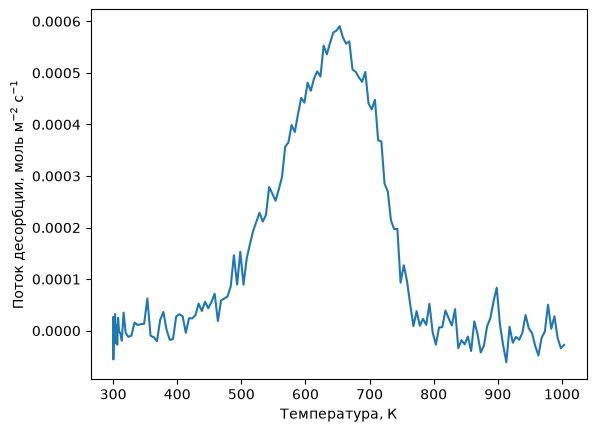

In [2]:
reference_parameters = [1e-2, 1.0]
reference_result = run_tds(
    *reference_parameters
)

reference_flux = (
    np.asarray(reference_result[0].data)
    + np.asarray(reference_result[1].data)
)
reference_temperature = temperature(
    np.asarray(reference_result[0].t)
)

rng = np.random.default_rng(42)
noise = rng.normal(
    0.0,
    0.05 * reference_flux.max(),
    reference_flux.size,
)
noisy_flux = reference_flux + noise

np.savetxt(
    "Noisy_TDS.csv",
    np.column_stack(
        [reference_temperature, noisy_flux]
    ),
    delimiter=";",
)

plt.plot(
    reference_temperature,
    noisy_flux,
)
plt.xlabel("Температура, К")
plt.ylabel(
    r"Поток десорбции, моль м$^{-2}$ с$^{-1}$"
)
plt.show()


## Целевая функция

Для каждого набора параметров выполняется расчёт ТДС. Ошибка определяется как среднее абсолютное отклонение от тестовых данных.


In [3]:
from scipy.interpolate import interp1d

reference = np.genfromtxt(
    "Noisy_TDS.csv",
    delimiter=";",
)

parameter_history = []
error_history = []
temperature_history = []
flux_history = []


def error_function(parameters):
    trap_fraction, detrapping_energy = parameters

    if (
        trap_fraction < 0.0
        or detrapping_energy < 0.0
    ):
        return 1e30

    result = run_tds(
        trap_fraction,
        detrapping_energy,
    )

    flux = (
        np.asarray(result[0].data)
        + np.asarray(result[1].data)
    )
    temperature_grid = temperature(
        np.asarray(result[0].t)
    )

    interpolated_flux = interp1d(
        temperature_grid,
        flux,
        fill_value="extrapolate",
    )

    error = np.mean(
        np.abs(
            interpolated_flux(reference[:, 0])
            - reference[:, 1]
        )
    )

    parameter_history.append(
        np.array(parameters, dtype=float)
    )
    error_history.append(error)
    temperature_history.append(temperature_grid)
    flux_history.append(flux)

    print(
        f"n={trap_fraction:.4g}, "
        f"E_p={detrapping_energy:.4g} эВ, "
        f"ошибка={error:.3e}"
    )

    return error


## Оптимизация

Используется метод Нелдера — Мида с начальным приближением $n=0.02$, $E_p=1.1$ эВ.


In [4]:
from scipy.optimize import minimize

initial_guess = np.array([2e-2, 1.1])

fit_result = minimize(
    error_function,
    initial_guess,
    method="Nelder-Mead",
    options={
        "disp": True,
        "fatol": 3e18,
        "xatol": 1e-2,
    },
)

print("Найденные параметры:", fit_result.x)


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

n=0.02, E_p=1.1 эВ, ошибка=1.711e-04


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

n=0.021, E_p=1.1 эВ, ошибка=1.815e-04


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

...

n=0.009978, E_p=1.003 эВ, ошибка=2.031e-05


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

n=0.01055, E_p=0.9915 эВ, ошибка=2.420e-05


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

n=0.009624, E_p=1.001 эВ, ошибка=2.018e-05
Optimization terminated successfully.
         Current function value: 0.000020
         Iterations: 18
         Function evaluations: 33
Найденные параметры: [0.00962389 1.00104179]


## Результат


Solving HydrogenTransportProblem:   0%|          | 0.00/140 [00:00<?, ?it/s]

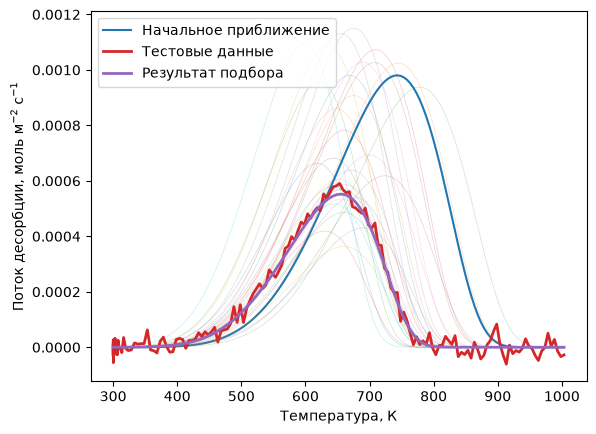

In [5]:
fitted_result = run_tds(*fit_result.x)

fitted_temperature = temperature(
    np.asarray(fitted_result[0].t)
)
fitted_flux = (
    np.asarray(fitted_result[0].data)
    + np.asarray(fitted_result[1].data)
)

for index, (
    temperature_grid,
    flux,
) in enumerate(
    zip(
        temperature_history,
        flux_history,
    )
):
    plt.plot(
        temperature_grid,
        flux,
        linewidth=(
            1.5 if index == 0 else 0.5
        ),
        alpha=(
            1.0 if index == 0 else 0.25
        ),
        label=(
            "Начальное приближение"
            if index == 0
            else None
        ),
    )

plt.plot(
    reference[:, 0],
    reference[:, 1],
    linewidth=2,
    label="Тестовые данные",
)
plt.plot(
    fitted_temperature,
    fitted_flux,
    linewidth=2,
    label="Результат подбора",
)

plt.xlabel("Температура, К")
plt.ylabel(
    r"Поток десорбции, моль м$^{-2}$ с$^{-1}$"
)
plt.legend()
plt.show()


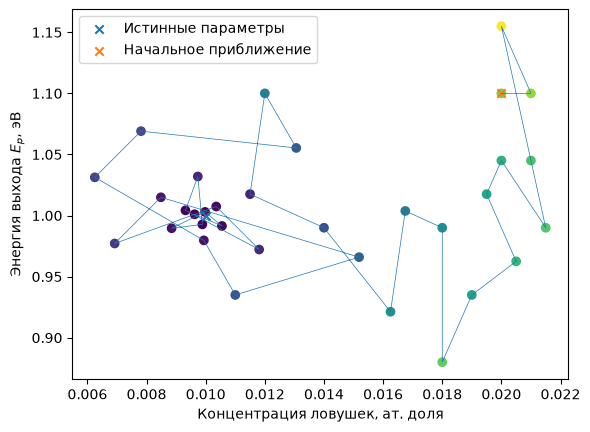

In [6]:
parameters = np.asarray(parameter_history)

plt.scatter(
    parameters[:, 0],
    parameters[:, 1],
    c=np.asarray(error_history),
)
plt.plot(
    parameters[:, 0],
    parameters[:, 1],
    linewidth=0.5,
)

plt.scatter(
    *reference_parameters,
    marker="x",
    label="Истинные параметры",
)
plt.scatter(
    *initial_guess,
    marker="x",
    label="Начальное приближение",
)

plt.xlabel("Концентрация ловушек, ат. доля")
plt.ylabel(r"Энергия выхода $E_p$, эВ")
plt.legend()
plt.show()
